# 17 — CMEMS Wave Boundary Conditions for v03b

Replaces the constant JONSWAP boundaries in v03 with time-varying Hs/Tp/Dir series
extracted from CMEMS MEDSEA wave reanalysis.

**Pipeline:**
1. Load CMEMS NetCDF downloaded by `scripts/download_cmems_waves.py`
2. Sample 3 points per boundary (W/S/N) → 9 time series
3. Write one `.bct`-style file per segment
4. Rewrite `model/dflowfm_v03b/wave/stagnone.mdw` with 9 segmented boundaries
5. Visual QA against the old constant setup

**Target**: `model/dflowfm_v03b/` (v03a stays untouched as reference).

## 1. Setup

In [1]:
# %matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
cmems_dir = project_root / 'data' / 'raw' / 'cmems'
v03b_dir = project_root / 'model' / 'dflowfm_v03b'
wave_dir = v03b_dir / 'wave'
fig_dir = project_root / 'figures'

# Time window (match MDU startDateTime/stopDateTime)
T_START = pd.Timestamp('2025-07-01 00:00:00')
T_STOP  = pd.Timestamp('2025-07-10 00:00:00')
REF_DATE = pd.Timestamp('2025-01-01 00:00:00')   # MDW ReferenceDate

# 3 offshore sample points per boundary (9 total). Positioned just outside
# the outer SWAN grid (lon 11.95-12.57, lat 37.69-38.07) to capture along-
# boundary gradients without hitting NaN land cells.
SAMPLE_POINTS = {
    'west':  [('seg1', 11.90, 37.75), ('seg2', 11.90, 37.88), ('seg3', 11.90, 38.00)],
    'south': [('seg1', 12.05, 37.67), ('seg2', 12.25, 37.67), ('seg3', 12.45, 37.67)],
    'north': [('seg1', 12.10, 38.08), ('seg2', 12.30, 38.08), ('seg3', 12.50, 38.08)],
}

# Geometry of each segment on the outer boundary (for the MDW StartCoord/EndCoord)
# West edge (x=11.95), split into 3 lat intervals
# South edge (y=37.69), split into 3 lon intervals
# North edge (y=38.07), split into 3 lon intervals
SEGMENTS = {
    'west':  [('seg1', (11.9500, 37.6900), (11.9500, 37.8173)),
              ('seg2', (11.9500, 37.8173), (11.9500, 37.9446)),
              ('seg3', (11.9500, 37.9446), (11.9500, 38.0716))],
    'south': [('seg1', (11.9500, 37.6900), (12.1563, 37.6900)),
              ('seg2', (12.1563, 37.6900), (12.3625, 37.6900)),
              ('seg3', (12.3625, 37.6900), (12.5688, 37.6900))],
    'north': [('seg1', (11.9500, 38.0716), (12.1563, 38.0716)),
              ('seg2', (12.1563, 38.0716), (12.3625, 38.0716)),
              ('seg3', (12.3625, 38.0716), (12.5688, 38.0716))],
}

print(f'Project root: {project_root}')
print(f'v03b wave dir: {wave_dir}')
print(f'CMEMS dir:    {cmems_dir}')

Project root: c:\Users\Unipa\Documents\StagnoneDT
v03b wave dir: c:\Users\Unipa\Documents\StagnoneDT\model\dflowfm_v03b\wave
CMEMS dir:    c:\Users\Unipa\Documents\StagnoneDT\data\raw\cmems


## 2. Load CMEMS wave reanalysis

Run `python scripts/download_cmems_waves.py` first. The expected file is
`data/raw/cmems/MEDSEA_WAV_20250701_20250710.nc`.

In [2]:
cmems_files = sorted(cmems_dir.glob('MEDSEA_WAV_*.nc'))
assert cmems_files, f'No CMEMS wave file found in {cmems_dir}. Run scripts/download_cmems_waves.py first.'
ds = xr.open_dataset(cmems_files[-1])
print(ds)

# Standardize coordinate names (CMEMS uses longitude/latitude typically)
if 'longitude' in ds.coords:
    ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})
print(f'\nTime range: {str(ds.time.values[0])} to {str(ds.time.values[-1])}')
print(f'Spatial: lon {float(ds.lon.min()):.3f}-{float(ds.lon.max()):.3f}, '
      f'lat {float(ds.lat.min()):.3f}-{float(ds.lat.max()):.3f}')
print(f'Variables: {list(ds.data_vars)}')

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 240, latitude: 10, longitude: 18)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2025-07-01 ... 2025-07-10T23:00:00
  * latitude   (latitude) float32 40B 37.69 37.73 37.77 ... 37.98 38.02 38.06
  * longitude  (longitude) float32 72B 11.88 11.92 11.96 ... 12.5 12.54 12.58
Data variables:
    VHM0       (time, latitude, longitude) float64 346kB ...
    VTPK       (time, latitude, longitude) float64 346kB ...
    VMDR       (time, latitude, longitude) float64 346kB ...
Attributes: (12/14)
    Conventions:               CF-1.6
    area:                      MED
    bulletin_date:             2023-11-01
    bulletin_type:             analysis
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    ...                        ...
    institution:               Hellenic Centre for Marine Research (HCMR)-Ath...
    producer:                  CME

## 3. Spatial overview

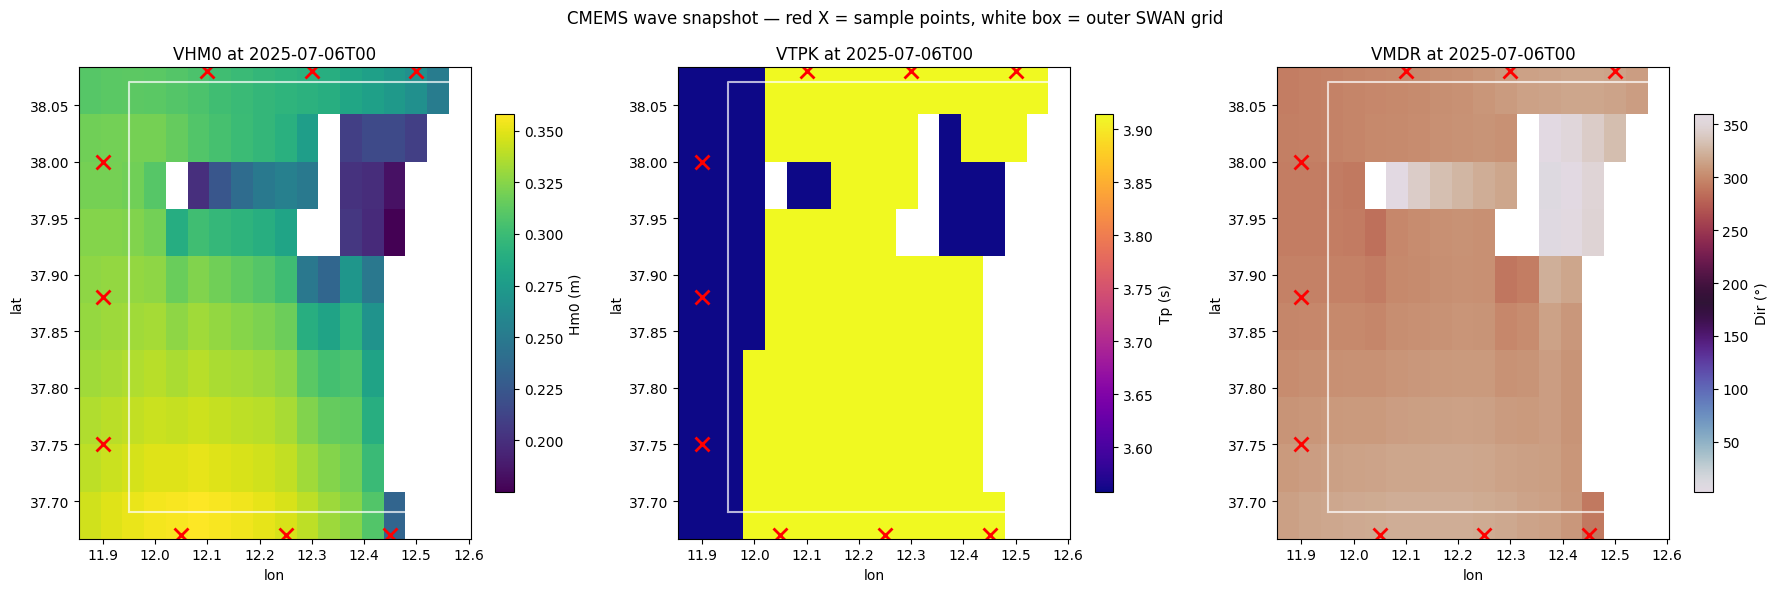

In [3]:
mid_time = ds.time.values[len(ds.time) // 2]
snap = ds.sel(time=mid_time)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, var, label, cmap in [
    (axes[0], 'VHM0', 'Hm0 (m)', 'viridis'),
    (axes[1], 'VTPK', 'Tp (s)',  'plasma'),
    (axes[2], 'VMDR', 'Dir (°)', 'twilight'),
]:
    im = ax.pcolormesh(snap.lon, snap.lat, snap[var], cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax, label=label, shrink=0.8)
    ax.set_title(f'{var} at {str(mid_time)[:13]}')
    # overlay sample points
    for boundary, pts in SAMPLE_POINTS.items():
        for name, lo, la in pts:
            ax.plot(lo, la, 'rx', ms=10, mew=2)
    # outer SWAN grid box
    ax.plot([11.95, 12.57, 12.57, 11.95, 11.95],
            [37.69, 37.69, 38.07, 38.07, 37.69], 'w-', lw=1.5, alpha=0.7)
    ax.set_xlabel('lon'); ax.set_ylabel('lat')
fig.suptitle(f'CMEMS wave snapshot — red X = sample points, white box = outer SWAN grid')
fig.tight_layout(); plt.show()

## 4. Extract time series at sample points

In [4]:
def extract_series(ds, lon, lat):
    """Nearest-neighbor time series at a point. Checks for NaN and shifts offshore if needed."""
    pt = ds.sel(lon=lon, lat=lat, method='nearest')
    nan_frac = float(np.isnan(pt['VHM0']).mean())
    if nan_frac > 0.1:
        print(f'  WARNING: point ({lon:.3f}, {lat:.3f}) has {nan_frac*100:.0f}% NaN in VHM0')
    return pt


series_by_boundary = {}
for boundary, pts in SAMPLE_POINTS.items():
    series_by_boundary[boundary] = {}
    for name, lo, la in pts:
        pt = extract_series(ds, lo, la)
        series_by_boundary[boundary][name] = pt
        hs_med = float(pt['VHM0'].median())
        tp_med = float(pt['VTPK'].median())
        dir_med = float(pt['VMDR'].median())
        print(f'  {boundary}/{name}  ({lo:.3f}, {la:.3f})  median: Hs={hs_med:.2f}m  Tp={tp_med:.1f}s  Dir={dir_med:.0f}°')

  west/seg1  (11.900, 37.750)  median: Hs=0.36m  Tp=4.3s  Dir=304°
  west/seg2  (11.900, 37.880)  median: Hs=0.36m  Tp=4.3s  Dir=306°
  west/seg3  (11.900, 38.000)  median: Hs=0.35m  Tp=4.3s  Dir=301°
  south/seg1  (12.050, 37.670)  median: Hs=0.37m  Tp=4.3s  Dir=304°
  south/seg2  (12.250, 37.670)  median: Hs=0.36m  Tp=4.3s  Dir=312°
  south/seg3  (12.450, 37.670)  median: Hs=0.28m  Tp=4.3s  Dir=287°
  north/seg1  (12.100, 38.080)  median: Hs=0.33m  Tp=4.3s  Dir=306°
  north/seg2  (12.300, 38.080)  median: Hs=0.33m  Tp=4.3s  Dir=312°
  north/seg3  (12.500, 38.080)  median: Hs=0.30m  Tp=4.3s  Dir=325°


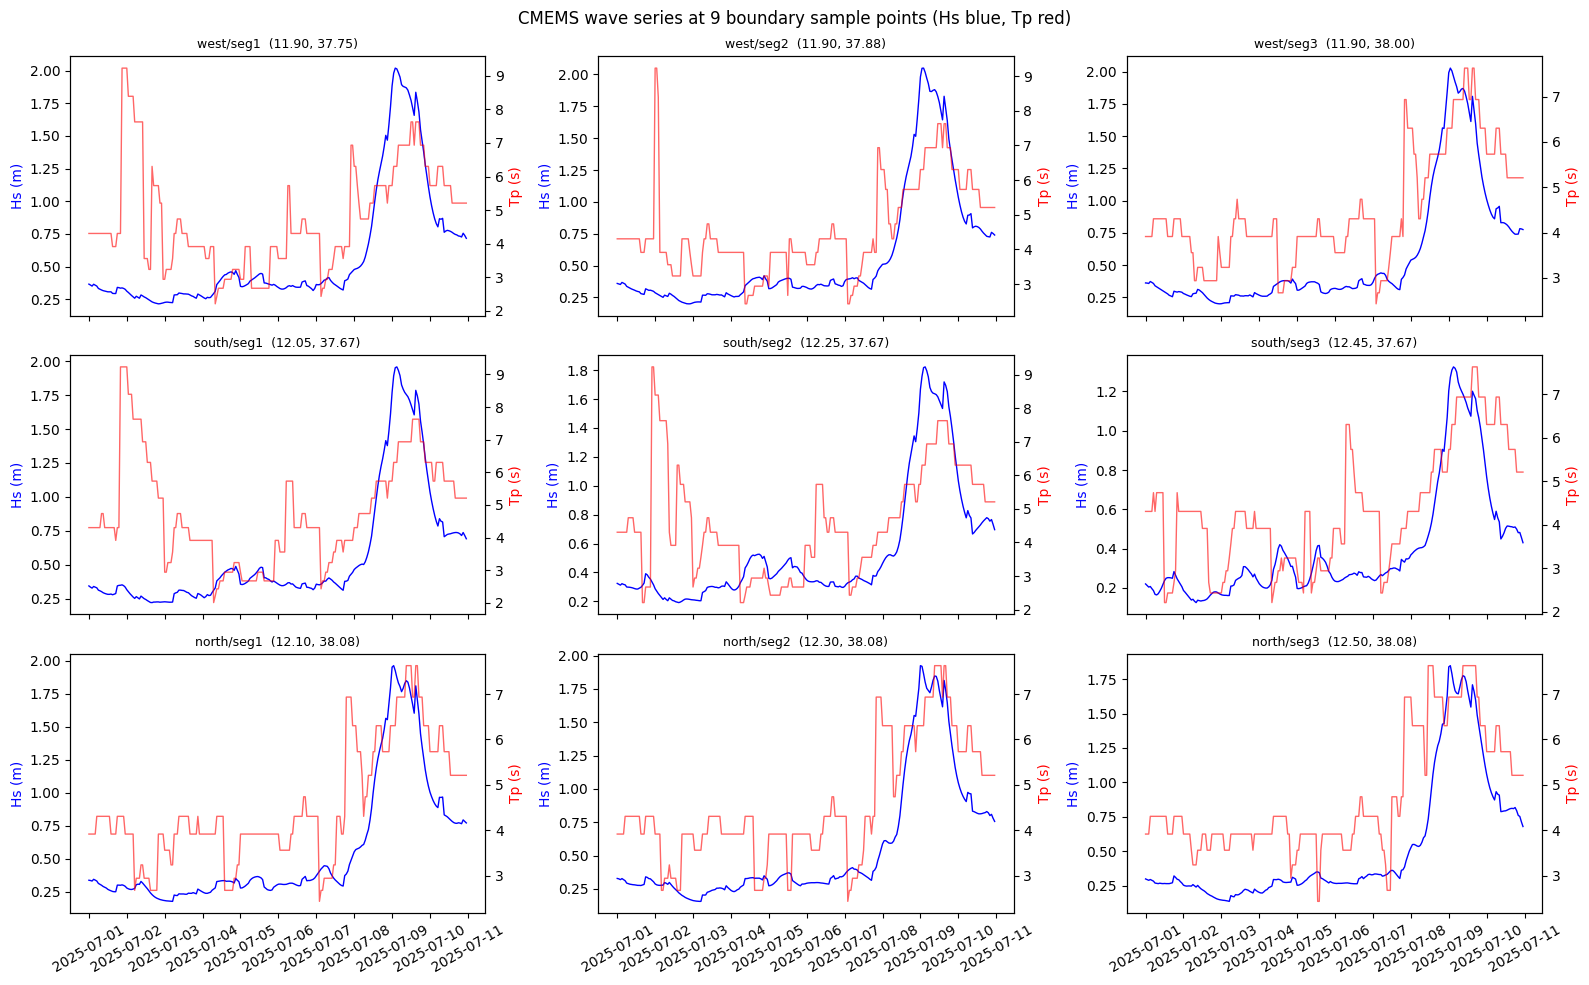

In [5]:
# Plot the 9 time series
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for row, (boundary, pts) in enumerate(SAMPLE_POINTS.items()):
    for col, (name, lo, la) in enumerate(pts):
        pt = series_by_boundary[boundary][name]
        ax = axes[row, col]
        ax.plot(pt.time, pt['VHM0'], 'b-', lw=1, label='Hs')
        ax2 = ax.twinx()
        ax2.plot(pt.time, pt['VTPK'], 'r-', lw=1, alpha=0.6, label='Tp')
        ax.set_title(f'{boundary}/{name}  ({lo:.2f}, {la:.2f})', fontsize=9)
        ax.set_ylabel('Hs (m)', color='b'); ax2.set_ylabel('Tp (s)', color='r')
        ax.tick_params(axis='x', rotation=30)
fig.suptitle('CMEMS wave series at 9 boundary sample points (Hs blue, Tp red)')
fig.tight_layout(); plt.show()

## 5. Write per-segment time-series files (`.bct`)

Format: plain text, whitespace-separated, one header line listing columns.
Time column is **minutes since MDW ReferenceDate** (2025-01-01 00:00:00).

```
time_minutes  Hs  Tp  Dir  DirSpreading
0.0           0.42  4.8  268.3  4.0
60.0          0.45  4.9  270.1  4.0
...
```

In [6]:
DIR_SPREAD = 4.0  # keep power-law spreading as in the original MDW

def write_bct(path, pt):
    df = pd.DataFrame({
        'time_min': (pt.time.values - np.datetime64(REF_DATE)).astype('timedelta64[m]').astype(float),
        'Hs':       pt['VHM0'].values,
        'Tp':       pt['VTPK'].values,
        'Dir':      pt['VMDR'].values,
    })
    # Fill isolated NaN via linear interpolation; drop leading/trailing
    df = df.set_index('time_min').interpolate(limit=3).dropna().reset_index()
    df['DirSpread'] = DIR_SPREAD
    with open(path, 'w') as f:
        f.write('* time_minutes  Hs(m)  Tp(s)  Dir(deg,nautical)  DirSpreading\n')
        for _, r in df.iterrows():
            f.write(f'{r.time_min:12.1f}  {r.Hs:6.3f}  {r.Tp:6.2f}  {r.Dir:7.2f}  {r.DirSpread:5.2f}\n')
    return len(df)


wave_dir.mkdir(parents=True, exist_ok=True)
written = {}
for boundary, pts in SAMPLE_POINTS.items():
    for name, lo, la in pts:
        out = wave_dir / f'{boundary}_{name}.bct'
        n = write_bct(out, series_by_boundary[boundary][name])
        written[f'{boundary}_{name}'] = (out, n)
        print(f'  {out.name}: {n} rows')

  west_seg1.bct: 240 rows
  west_seg2.bct: 240 rows
  west_seg3.bct: 240 rows
  south_seg1.bct: 240 rows
  south_seg2.bct: 240 rows
  south_seg3.bct: 240 rows
  north_seg1.bct: 240 rows
  north_seg2.bct: 240 rows
  north_seg3.bct: 240 rows


## 6. Rewrite the MDW with 9 segmented boundaries

Back up the original first, then inject new boundary sections while preserving
all other sections (`[General]`, `[Constants]`, `[Processes]`, `[Numerics]`,
`[Output]`, both `[Domain]` sections).

In [7]:
mdw_path = wave_dir / 'stagnone.mdw'
bak_path = wave_dir / 'stagnone.mdw.bak'

# Backup once
if not bak_path.exists():
    bak_path.write_text(mdw_path.read_text())
    print(f'Backup: {bak_path}')

original = bak_path.read_text()

# Strip all existing [Boundary] sections (everything from first [Boundary] to EOF
# if followed only by Boundary sections, else up to next non-Boundary section)
lines = original.splitlines()
keep = []
in_bnd = False
for line in lines:
    stripped = line.strip()
    if stripped.startswith('[Boundary]'):
        in_bnd = True
        continue
    if in_bnd and stripped.startswith('[') and not stripped.startswith('[Boundary]'):
        in_bnd = False
    if not in_bnd:
        keep.append(line)

head = '\n'.join(keep).rstrip() + '\n\n'

# Compass direction (for reference in comments)
ORIENTATION_MAP = {'west': 'west', 'south': 'south', 'north': 'north'}

sections = []
for boundary, segs in SEGMENTS.items():
    for name, start, end in segs:
        bct = f'{boundary}_{name}.bct'
        sec = (
            f'[Boundary]\n'
            f'   Name             = {boundary}_{name}\n'
            f'   Definition       = xy\n'
            f'   StartCoord       = ({start[0]:.4f}, {start[1]:.4f})\n'
            f'   EndCoord         = ({end[0]:.4f}, {end[1]:.4f})\n'
            f'   SpectrumSpec     = parametric\n'
            f'   SpShapeType      = jonswap\n'
            f'   PeriodType       = peak\n'
            f'   DirSpreadType    = power\n'
            f'   PeakEnhanceFac   = 3.3\n'
            f'   GaussSpread      = 0.01\n'
            f'   TimeseriesFile   = {bct}\n'
        )
        sections.append(sec)

new_mdw = head + '\n'.join(sections)
mdw_path.write_text(new_mdw)
print(f'Wrote: {mdw_path}  ({len(sections)} [Boundary] sections)')

Backup: c:\Users\Unipa\Documents\StagnoneDT\model\dflowfm_v03b\wave\stagnone.mdw.bak
Wrote: c:\Users\Unipa\Documents\StagnoneDT\model\dflowfm_v03b\wave\stagnone.mdw  (9 [Boundary] sections)


## 7. QA comparison: constant (v03a) vs time-varying (v03b)

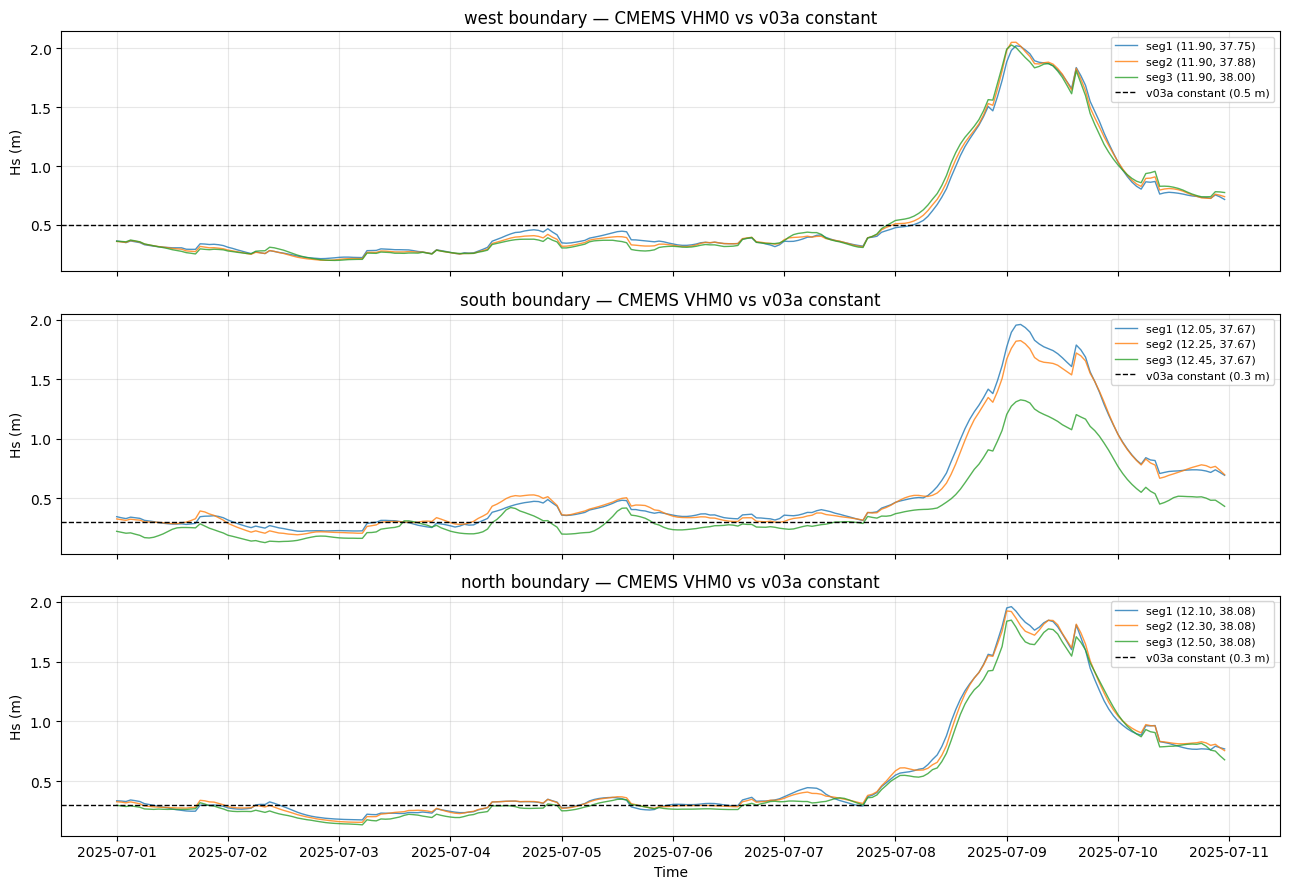

In [8]:
OLD_HS = {'west': 0.5, 'south': 0.3, 'north': 0.3}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (boundary, pts) in zip(axes, SAMPLE_POINTS.items()):
    for name, lo, la in pts:
        pt = series_by_boundary[boundary][name]
        ax.plot(pt.time, pt['VHM0'], lw=1.0, alpha=0.8, label=f'{name} ({lo:.2f}, {la:.2f})')
    ax.axhline(OLD_HS[boundary], color='k', ls='--', lw=1.0, label=f'v03a constant ({OLD_HS[boundary]} m)')
    ax.set_title(f'{boundary} boundary — CMEMS VHM0 vs v03a constant')
    ax.set_ylabel('Hs (m)')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Time')
fig.tight_layout()
fig.savefig(str(fig_dir / 'v03b_boundary_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Next steps

- Run `run_dimr.sh -m dimr_config.xml` in `model/dflowfm_v03b/` to validate MDW parsing
- Inspect `wave/swn-diag.stagnone` for any `** Error` on boundary files
- Short 1-day sub-window test before full 9-day run
- Compare wave fields (`wavm-stagnone-swan_grid.nc`) vs v03a